## **MCF7 - Smart Sequence - EDA**

### **Introduction**


<p style="font-size:15px; line-height:1.6;">This project was carried out as part of the AI Lab at Bocconi University and aims to understand how different oxygen conditions, mainly normoxia and hypoxia, influence the gene expression patterns in cells. Specifically, oxygen levels are of critical importance in numerous biological processes such as cell growth, metabolism and energy production. Therefore, by studying the changes in gene expression under normal and low oxygen levels, we can delve deeper into the mechanisms that enable cellular adaptation and survival in hypoxic environments. </p>

<p style="font-size:15px; line-height:1.6;">The main focus of this study involves two complementary single-cell RNA sequencing methods; namely, Smart-Seq and Drop-Seq. These provide detailed gene expression profiles of individual cells with high resolution and allow us to capture the heterogeneity of cells as well as subtle transcriptional changes across conditions. While Smart-Seq is typically applied to a smaller number of cells, it provides highly detailed gene expression measurements. Drop-Seq, on the other hand, is faster, but provides a lower resolution per cell.</p>

<p style="font-size:15px; line-height:1.6;">Our analysis focuses on two cancer cell lines: HCC1806 and MCF7, which are widely studied breast cancer cell lines. The first is an aggressive type of tumor in which hypoxia is the common feature that contributes to its progression, metastasis, and its therapy resistance. The second cell line provides a model for a highly heterogeneous disease with numerous treatment responses. Therefore, studying these cell lines under low oxygen conditions may provide significant insights into the key mechanisms that drive these processes. </p>

<p style="font-size:15px; line-height:1.6;">From a technical perspective, the dataset contains columns, which represent an individual cell labelled according to its oxygen conditions and rows that correspond to a gene with its unique gene symbol. This allows us to direct comparison of the gene expression across cells and conditions. </p>

<p style="font-size:15px; line-height:1.6;">The overall goal is to identify and interpret the main transcriptional changes associated with hypoxia in these cancer cell lines. In this notebook, we will perform the Exploratory Data Analysis for the MCF7 Smart-Seq.</p>




#### **Structure of the file**

1. **EDA (Exploratory Data Analysis)**
    - Metadata Files: General Analysis

    - MCF7 Unfiltered Data:
        * General Information

        * Missing Values
        * Duplicate Genes
        * Cells' correlation
        * Outliers
        * Plots
        * Sparsity 
        * Data Distribution 
    
2. **Data preprocessing:**
    - Quality Control/ Filtering

    - Data Transformations
    - Normalization
    - Feature Selection and Comparison with Filtered Dataset



#### **Libraries**

These are the libraries that we need for the purpose of the Exploratory Data Analysis.

In [679]:
import sys
import sklearn
import pandas as pd
import numpy as np  
import seaborn as sns   
import random
import matplotlib.pyplot as plt

from matplotlib import ticker
from scipy.stats import kurtosis, skew
from sklearn.preprocessing import StandardScaler

%matplotlib inline     
sns.set(color_codes=True)


We start with the Exploratory Data Analysis.

### **Exploratory Data Analysis**


First step of the EDA is to briefly investigate the metadata file. 

#### **Metadata file**

We read the metadata file by importing it and looking at its structure.


In [680]:
meta = pd.read_csv("/Users/nikimaz/Documents/Bocconi Courses Year Two 2025-2026/AI LAB/MCF7_SmartS_MetaData.tsv",delimiter="\t",engine='python',index_col=0)
print("Dataframe dimensions:", np.shape(meta))
print("First column: ", meta.iloc[ : , 0])

Dataframe dimensions: (383, 8)
First column:  Filename
output.STAR.1_A10_Hypo_S28_Aligned.sortedByCoord.out.bam    MCF7
output.STAR.1_A11_Hypo_S29_Aligned.sortedByCoord.out.bam    MCF7
output.STAR.1_A12_Hypo_S30_Aligned.sortedByCoord.out.bam    MCF7
output.STAR.1_A1_Norm_S1_Aligned.sortedByCoord.out.bam      MCF7
output.STAR.1_A2_Norm_S2_Aligned.sortedByCoord.out.bam      MCF7
                                                            ... 
output.STAR.4_H5_Norm_S359_Aligned.sortedByCoord.out.bam    MCF7
output.STAR.4_H6_Norm_S360_Aligned.sortedByCoord.out.bam    MCF7
output.STAR.4_H7_Hypo_S379_Aligned.sortedByCoord.out.bam    MCF7
output.STAR.4_H8_Hypo_S380_Aligned.sortedByCoord.out.bam    MCF7
output.STAR.4_H9_Hypo_S381_Aligned.sortedByCoord.out.bam    MCF7
Name: Cell Line, Length: 383, dtype: object


In [681]:
meta.head(5)   

,Cell Line,Lane,Pos,Condition,Hours,Cell name,PreprocessingTag,ProcessingComments
Filename,,,,,,,,
output.STAR.1_A10_Hypo_S28_Aligned.sortedByCoord.out.bam,MCF7,output.STAR.1,A10,Hypo,72,S28,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
output.STAR.1_A11_Hypo_S29_Aligned.sortedByCoord.out.bam,MCF7,output.STAR.1,A11,Hypo,72,S29,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
output.STAR.1_A12_Hypo_S30_Aligned.sortedByCoord.out.bam,MCF7,output.STAR.1,A12,Hypo,72,S30,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
output.STAR.1_A1_Norm_S1_Aligned.sortedByCoord.out.bam,MCF7,output.STAR.1,A1,Norm,72,S1,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
output.STAR.1_A2_Norm_S2_Aligned.sortedByCoord.out.bam,MCF7,output.STAR.1,A2,Norm,72,S2,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"


**Further Information about the dataset**

<p style="font-size:15px; line-height:1.6;">
The MetaData has 383 rows, representing a different cell of the same cell line, and 8 columns which are: 


- __Filename__ : The name of the file gives you information on cell line, the technology used and processing. The format is: CellLine_Technology_preprocessing_Data.txt  

- __Cell Line__:In this case, the cell line is MCF7, which is derived from a breast tumor tissue. The sum of these cells were taken from a single cell source and was cultured under laboratory conditions.

- __Lane__: indicated where the sample was processed. There are four different lanes.


- __Pos__: refers to the position of the sample in the respective plates. 


- __Condition__: indicates whether the sample was Normoxic or Hypoxic 


- __Hours__: indicates the number of hours the sample was grown for. We infer that all samples were grown for 72 hours.

- __Cell name__:   indicates the name of the cell sample.

- __PreprocessingTag__: indicates the preprocessing. It is the same for all values.

   <p style="font-size:15px; line-height:1.6;"> In particular:

   - Aligned.sortedByCoord refers to the fact that the reads (the RNA sequence from one fragment) have been organized based on the specific position on the genome.
   
   - \out.bam indicates the output has been saved as a Binary Alignment Map file (BAM), namely a compressed version of a Sequence Alignment Map (SAM) file.</p>

- __ProcessingComments__: 
    indicates additional information on the processing of the sample. 
   <p style="font-size:15px; line-height:1.6;"> - STAR indicates the type of alignment conducted.</p>
    
    <p style="font-size:15px; line-height:1.6;">- FeatureCounts is just the name of the software used.</p>

We first verify that there are no duplicates cell names in the metadata:


In [682]:
names = [i for i in meta["Cell name"]]
assert len(names) == len(set(names))

In [683]:
meta.describe(include='all')

,Cell Line,Lane,Pos,Condition,Hours,Cell name,PreprocessingTag,ProcessingComments
count,383,383,383,383,383.0,383,383,383
unique,1,4,98,2,NaN,383,1,1
top,MCF7,output.STAR.1,A10,Norm,NaN,S28,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
freq,383,96,4,192,NaN,1,383,383
mean,NaN,NaN,NaN,NaN,72.0,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,72.0,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,72.0,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,72.0,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,72.0,NaN,NaN,NaN


Now, we will count how many Norm and Hypo cells there are:


Condition
Norm    192
Hypo    191
Name: count, dtype: int64


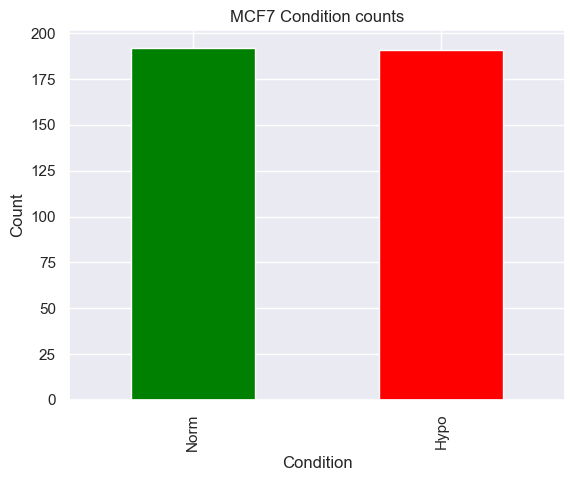

In [684]:
counts = meta['Condition'].value_counts()
# Histogram of the counts
print(counts)
# Plot the histogram with two columns for each condition
counts.plot(kind='bar', color=['green', 'red'])
plt.title('MCF7 Condition counts')
plt.xlabel('Condition')
plt.ylabel('Count')
plt.show()

<p style="font-size:15px; line-height:1.6;">So, as we can see, the dataset is balanced. Having a balanced dataset is very important before proceeding with the analysis of the sequencing of data. Specifically, an imbalanced dataset can negatively impact the model performance, as models tend to favor those classes that are overpresented, resulting in a biased learning and poorer generalization. In contrast, a balanced dataset, as in this case, helps the model to learn patterns effectively and become sufficient at predicting the correct classification.</p>


As of the missing values:

In [685]:
print(meta.isnull().sum())
for i in meta.isnull().sum():
    assert i == 0

Cell Line             0
Lane                  0
Pos                   0
Condition             0
Hours                 0
Cell name             0
PreprocessingTag      0
ProcessingComments    0
dtype: int64


There are no missing values, so the groups are well represented.


#### **MCF7 Smart_Seq - Unfiltered Dataset**

##### **General Information**

<p style="font-size:15px; line-height:1.6;">Having a brief insight of our data, we proceed with reading the unfiltered MCF7 Smart Sequencing dataset.</p>

In [686]:
unf = pd.read_csv("/Users/nikimaz/Documents/Bocconi Courses Year Two 2025-2026/AI LAB/MCF7_SmartS_Unfiltered_Data.txt",delimiter="\ ",engine='python',index_col=0)
print("Dataframe dimensions:", np.shape(unf))
print("First column: ", unf.iloc[ : , 0])
unf.shape
list(unf.columns)

Dataframe dimensions: (22934, 383)
First column:  "WASH7P"         0
"MIR6859-1"      0
"WASH9P"         1
"OR4F29"         0
"MTND1P23"       0
              ... 
"MT-TE"          4
"MT-CYB"       270
"MT-TT"          0
"MT-TP"          5
"MAFIP"          8
Name: "output.STAR.1_A10_Hypo_S28_Aligned.sortedByCoord.out.bam", Length: 22934, dtype: int64


['"output.STAR.1_A10_Hypo_S28_Aligned.sortedByCoord.out.bam"',
 '"output.STAR.1_A11_Hypo_S29_Aligned.sortedByCoord.out.bam"',
 '"output.STAR.1_A12_Hypo_S30_Aligned.sortedByCoord.out.bam"',
 '"output.STAR.1_A1_Norm_S1_Aligned.sortedByCoord.out.bam"',
 '"output.STAR.1_A2_Norm_S2_Aligned.sortedByCoord.out.bam"',
 '"output.STAR.1_A3_Norm_S3_Aligned.sortedByCoord.out.bam"',
 '"output.STAR.1_A4_Norm_S4_Aligned.sortedByCoord.out.bam"',
 '"output.STAR.1_A5_Norm_S5_Aligned.sortedByCoord.out.bam"',
 '"output.STAR.1_A6_Norm_S6_Aligned.sortedByCoord.out.bam"',
 '"output.STAR.1_A7_Hypo_S25_Aligned.sortedByCoord.out.bam"',
 '"output.STAR.1_A8_Hypo_S26_Aligned.sortedByCoord.out.bam"',
 '"output.STAR.1_A9_Hypo_S27_Aligned.sortedByCoord.out.bam"',
 '"output.STAR.1_B10_Hypo_S76_Aligned.sortedByCoord.out.bam"',
 '"output.STAR.1_B11_Hypo_S77_Aligned.sortedByCoord.out.bam"',
 '"output.STAR.1_B12_Hypo_S78_Aligned.sortedByCoord.out.bam"',
 '"output.STAR.1_B1_Norm_S49_Aligned.sortedByCoord.out.bam"',
 '"outpu

<p style="font-size:15px; line-height:1.6;">As we can see, the columns are the cells, whose names match those that we had in the metadata. The rows contain the genes.  More specifically:</p>

In [687]:
print("Data types in the dataframe:", unf.dtypes.unique())
gene_symbols = unf.index
print("Gene symbols in the dataframe:",gene_symbols)

Data types in the dataframe: [dtype('int64')]
Gene symbols in the dataframe: Index(['"WASH7P"', '"MIR6859-1"', '"WASH9P"', '"OR4F29"', '"MTND1P23"',
       '"MTND2P28"', '"MTCO1P12"', '"MTCO2P12"', '"MTATP8P1"', '"MTATP6P1"',
       ...
       '"MT-TH"', '"MT-TS2"', '"MT-TL2"', '"MT-ND5"', '"MT-ND6"', '"MT-TE"',
       '"MT-CYB"', '"MT-TT"', '"MT-TP"', '"MAFIP"'],
      dtype='object', length=22934)


In [688]:
numeric_columns = unf.select_dtypes(include=[np.number]).columns
all_numeric = len(numeric_columns) == len(unf.columns)
print(all_numeric)

True


<p style="font-size:15px; line-height:1.6;">As shown above, the type of data that we have is int64, which is ensures that the values are numeric and thus, suitable for computations. This will allow us to perform mathematical operations efficiently, avoiding the issues that are connected with non-numeric data.</p>

In [689]:
unf.shape

(22934, 383)

There are 22934 genes and 383 cells in this dataset.

In [690]:
unf.head()

,"""output.STAR.1_A10_Hypo_S28_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A11_Hypo_S29_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A12_Hypo_S30_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A1_Norm_S1_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A2_Norm_S2_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A3_Norm_S3_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A4_Norm_S4_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A5_Norm_S5_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A6_Norm_S6_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A7_Hypo_S25_Aligned.sortedByCoord.out.bam""",...,"""output.STAR.4_H14_Hypo_S383_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H1_Norm_S355_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H2_Norm_S356_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H3_Norm_S357_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H4_Norm_S358_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H5_Norm_S359_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H6_Norm_S360_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H7_Hypo_S379_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H8_Hypo_S380_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H9_Hypo_S381_Aligned.sortedByCoord.out.bam"""
"""WASH7P""",0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,1
"""MIR6859-1""",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"""WASH9P""",1,0,0,0,0,1,10,1,0,0,...,1,1,0,0,0,0,1,1,4,5
"""OR4F29""",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
"""MTND1P23""",0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


<p style="font-size:15px; line-height:1.6;">Each entry represents the expression levels of a gene in a cell, measured as the number of RNA reads within that cell. For example, WASH9P had 1 read in the cell S28. If a gene has a 0, this indicates that this specific gene was not detected in that cell sample.</p>

<p style="font-size:15px; line-height:1.6;">A gene with high expression of certain genes and low of others might correspond to a specific condition. Therefore, we want to build a strong ML model that will learn these pattern and predict its state. </p>

<p style="font-size:15px; line-height:1.6;">We transpose the original dataset, so that the rows represent the observations (samples) and the columns, the genes (variables). This is the standard format that is required for the machine learning methods. We will also remove the quotation marks in the features' name to simplify our analysis.  </p>

In [691]:
def remove_double_quotes(word):
    return word.replace('"', '')

In [692]:
unf = unf.rename(columns={"{}".format(i):"{}".format(remove_double_quotes(i)) for i in unf.columns})
unf = unf.T
unf = unf.rename(columns={"{}".format(i):"{}".format(remove_double_quotes(i)) for i in unf.columns})
print("Dataframe dimesions after Transposing:", np.shape(unf))

Dataframe dimesions after Transposing: (383, 22934)


Just a brief check:

In [693]:
unf.head()

,WASH7P,MIR6859-1,WASH9P,OR4F29,MTND1P23,MTND2P28,MTCO1P12,MTCO2P12,MTATP8P1,MTATP6P1,...,MT-TH,MT-TS2,MT-TL2,MT-ND5,MT-ND6,MT-TE,MT-CYB,MT-TT,MT-TP,MAFIP
output.STAR.1_A10_Hypo_S28_Aligned.sortedByCoord.out.bam,0,0,1,0,0,2,2,0,0,29,...,0,0,0,505,147,4,270,0,5,8
output.STAR.1_A11_Hypo_S29_Aligned.sortedByCoord.out.bam,0,0,0,0,0,0,0,0,0,0,...,1,1,0,1,0,0,1,0,0,0
output.STAR.1_A12_Hypo_S30_Aligned.sortedByCoord.out.bam,0,0,0,0,0,1,1,1,0,12,...,0,0,0,1,0,0,76,0,0,0
output.STAR.1_A1_Norm_S1_Aligned.sortedByCoord.out.bam,0,0,0,0,0,0,0,0,0,7,...,1,0,0,44,8,0,66,0,1,0
output.STAR.1_A2_Norm_S2_Aligned.sortedByCoord.out.bam,0,0,0,0,0,0,0,0,0,68,...,0,0,0,237,31,3,727,0,0,0


We, now, compute the summary statistics for each gene:

In [694]:
table = unf.describe()
table

,WASH7P,MIR6859-1,WASH9P,OR4F29,MTND1P23,MTND2P28,MTCO1P12,MTCO2P12,MTATP8P1,MTATP6P1,...,MT-TH,MT-TS2,MT-TL2,MT-ND5,MT-ND6,MT-TE,MT-CYB,MT-TT,MT-TP,MAFIP
count,383.000000,383.000000,383.000000,383.00000,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000,...,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000,383.00000,383.000000,383.000000,383.000000
mean,0.133159,0.026110,1.344648,0.05483,0.049608,6.261097,4.681462,0.524804,0.073107,222.054830,...,1.060052,0.443864,3.146214,1016.477807,204.600522,5.049608,2374.97389,2.083551,5.626632,1.749347
std,0.618664,0.249286,2.244543,0.31477,0.229143,7.565749,6.232649,0.980857,0.298131,262.616874,...,1.990566,1.090827,4.265352,1009.444811,220.781927,6.644302,2920.39000,3.372714,7.511180,3.895204
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,23.000000,...,0.000000,0.000000,0.000000,172.000000,30.500000,0.000000,216.50000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.00000,0.000000,3.000000,2.000000,0.000000,0.000000,98.000000,...,0.000000,0.000000,1.000000,837.000000,152.000000,3.000000,785.00000,0.000000,3.000000,0.000000
75%,0.000000,0.000000,2.000000,0.00000,0.000000,10.000000,7.000000,1.000000,0.000000,370.500000,...,1.000000,0.000000,5.000000,1549.000000,294.000000,7.000000,4059.00000,3.000000,8.000000,2.000000
max,9.000000,4.000000,20.000000,3.00000,2.000000,45.000000,36.000000,6.000000,2.000000,1662.000000,...,15.000000,8.000000,22.000000,8115.000000,2002.000000,46.000000,16026.00000,22.000000,56.000000,32.000000


<p style="font-size:15px; line-height:1.6;">As we can derive from the graph, each column corresponds to a gene, and the statistics are computed over 383 samples. The count is 383 for all genes, indicating no missing values. More specifically:</p>

- <p style="font-size:15px; line-height:1.6;">The mean expression is generally low for most genes, suggesting that many genes are weakly expressed.</p>

- <p style="font-size:15px; line-height:1.6;">The median (50%) is often 0, indicating that more than half of the cells show no expression for many genes.</p>

<p style="font-size:15px; line-height:1.6;">This highlights the __sparsity__ of the dataset, which is typical in single-cell RNA sequencing data (we will deal with it later in the report).</p>

- <p style="font-size:15px; line-height:1.6;">The maximum values are much higher than the mean, showing that some genes are highly expressed in a small subset of cells.</p>

- <p style="font-size:15px; line-height:1.6;">The high standard deviation for several genes indicates strong presence in some cells and low to none presence in others.</p>

<p style="font-size:15px; line-height:1.6;">In general, the important observations of the above are that the differences between the minimum and maximum indicate the existence of possible outliers as well as that there are a lot of 0 entries, indicating the sparsity of this dataset. We will deal with sparsity and outliers in the next sections.</p>

In [695]:
gene_sums = unf.sum(axis=0)

min_gene = gene_sums.idxmin()
print("Gene with the least total expression:", min_gene)
print("Total expression:", gene_sums.min())

max_gene = gene_sums.idxmax()
print("Gene with the most total expression:", max_gene)
print("Total expression:", gene_sums.max())

print("Global max is:", table.loc["max"].max())
print("Global min is:", table.loc["min"].min())

Gene with the least total expression: CICP3
Total expression: 2
Gene with the most total expression: KRT8
Total expression: 8829208
Global max is: 190556.0
Global min is: 0.0


##### **Missing Values**

In [696]:
print(unf.isnull().sum())
for i in unf.isnull().sum():
    assert i == 0

WASH7P       0
MIR6859-1    0
WASH9P       0
OR4F29       0
MTND1P23     0
            ..
MT-TE        0
MT-CYB       0
MT-TT        0
MT-TP        0
MAFIP        0
Length: 22934, dtype: int64


<p style="font-size:15px; line-height:1.6;">There are no missing values in the dataset, which ensures the completeness of the data and thus there is no need for imputations, which could potentially increase bias. </p>

##### **Duplicate Genes**

<p style="font-size:15px; line-height:1.6;">We want to see if there are genes that behave the same across all of the cells. To identify redundant genes, we apply data.T.duplicated(), which returns a boolean Series indicating which rows in the transposed dataset (i.e., the original columns corresponding to genes) are duplicates.</p>

In [697]:
duplicate_data = unf.T[unf.T.duplicated()]
print("Number of duplicate genes:", duplicate_data.shape[0], "over", unf.T.shape[0])
print("Percentage of duplicate genes:", (duplicate_data.shape[0] * 100) / (unf.T.shape[0]), "%")

Number of duplicate genes: 29 over 22934
Percentage of duplicate genes: 0.12644981250545043 %


<p style="font-size:15px; line-height:1.6;">Since there are duplicates, we want to understand which are equal to each other. "1" indicates that genes behave almost identically and "0" reveals no relation between the genes.</p>

In [698]:
duplicate_rows_df_t = duplicate_data.T
duplicate_rows_df_t
c_dupl = duplicate_rows_df_t.corr()
c_dupl

,KLF2P3,UGT1A9,SLC22A14,COQ10BP2,LAP3P2,GALNT17,PON1,MIR664B,KCNS2,MIR548D1,...,RBFOX1,ASPA,BCL6B,CCL3L1,OTOP3,RNA5SP450,PSG1,MIR3191,SEZ6L,ADAMTS5
KLF2P3,1.000000,-0.014798,-0.008333,-0.008333,-0.032300,-0.007903,-0.007903,-0.007142,-0.008333,-0.007903,...,-0.008333,-0.007903,-0.008333,-0.012088,-0.006928,-0.008333,-0.008333,-0.008333,-0.006775,-0.007903
UGT1A9,-0.014798,1.000000,-0.009322,-0.009322,-0.008675,-0.008841,-0.008841,-0.007990,-0.009322,-0.008841,...,-0.009322,-0.008841,-0.009322,-0.013523,-0.007750,-0.009322,-0.009322,-0.009322,-0.007579,-0.008841
SLC22A14,-0.008333,-0.009322,1.000000,0.497375,-0.020348,0.948434,0.948434,-0.004499,0.497375,-0.004979,...,0.497375,0.630630,0.497375,-0.007615,0.831379,-0.005249,0.497375,-0.005249,0.813013,0.630630
COQ10BP2,-0.008333,-0.009322,0.497375,1.000000,-0.020348,0.630630,0.630630,-0.004499,0.497375,-0.004979,...,0.497375,0.630630,0.497375,-0.007615,0.134926,-0.005249,0.497375,-0.005249,0.112487,0.630630
LAP3P2,-0.032300,-0.008675,-0.020348,-0.020348,1.000000,-0.019299,-0.019299,-0.017440,-0.020348,-0.019299,...,-0.020348,-0.019299,-0.020348,-0.013474,-0.016917,-0.020348,-0.020348,0.118817,-0.016543,-0.019299
GALNT17,-0.007903,-0.008841,0.948434,0.630630,-0.019299,1.000000,1.000000,-0.004267,0.630630,-0.004722,...,0.630630,0.799056,0.630630,-0.007222,0.612365,-0.004979,0.630630,-0.004979,0.586533,0.799056
PON1,-0.007903,-0.008841,0.948434,0.630630,-0.019299,1.000000,1.000000,-0.004267,0.630630,-0.004722,...,0.630630,0.799056,0.630630,-0.007222,0.612365,-0.004979,0.630630,-0.004979,0.586533,0.799056
MIR664B,-0.007142,-0.007990,-0.004499,-0.004499,-0.017440,-0.004267,-0.004267,1.000000,-0.004499,-0.004267,...,-0.004499,-0.004267,-0.004499,0.007958,-0.003741,-0.004499,-0.004499,-0.004499,-0.003658,-0.004267
KCNS2,-0.008333,-0.009322,0.497375,0.497375,-0.020348,0.630630,0.630630,-0.004499,1.000000,-0.004979,...,0.497375,0.630630,1.000000,0.021357,0.134926,-0.005249,0.497375,-0.005249,0.112487,0.948434
MIR548D1,-0.007903,-0.008841,-0.004979,-0.004979,-0.019299,-0.004722,-0.004722,-0.004267,-0.004979,1.000000,...,-0.004979,-0.004722,-0.004979,-0.007222,-0.004139,-0.004979,-0.004979,-0.004979,-0.004048,-0.004722


So, we remove the duplicates.

In [699]:
unf_nodup = unf.T.drop_duplicates(inplace=False)
unf_nodup.T

,WASH7P,MIR6859-1,WASH9P,OR4F29,MTND1P23,MTND2P28,MTCO1P12,MTCO2P12,MTATP8P1,MTATP6P1,...,MT-TH,MT-TS2,MT-TL2,MT-ND5,MT-ND6,MT-TE,MT-CYB,MT-TT,MT-TP,MAFIP
output.STAR.1_A10_Hypo_S28_Aligned.sortedByCoord.out.bam,0,0,1,0,0,2,2,0,0,29,...,0,0,0,505,147,4,270,0,5,8
output.STAR.1_A11_Hypo_S29_Aligned.sortedByCoord.out.bam,0,0,0,0,0,0,0,0,0,0,...,1,1,0,1,0,0,1,0,0,0
output.STAR.1_A12_Hypo_S30_Aligned.sortedByCoord.out.bam,0,0,0,0,0,1,1,1,0,12,...,0,0,0,1,0,0,76,0,0,0
output.STAR.1_A1_Norm_S1_Aligned.sortedByCoord.out.bam,0,0,0,0,0,0,0,0,0,7,...,1,0,0,44,8,0,66,0,1,0
output.STAR.1_A2_Norm_S2_Aligned.sortedByCoord.out.bam,0,0,0,0,0,0,0,0,0,68,...,0,0,0,237,31,3,727,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
output.STAR.4_H5_Norm_S359_Aligned.sortedByCoord.out.bam,0,0,0,0,0,0,1,0,0,49,...,0,0,1,341,46,1,570,0,0,0
output.STAR.4_H6_Norm_S360_Aligned.sortedByCoord.out.bam,0,0,1,0,0,2,5,5,0,370,...,0,0,2,1612,215,6,3477,3,7,6
output.STAR.4_H7_Hypo_S379_Aligned.sortedByCoord.out.bam,1,0,1,0,0,7,0,0,0,33,...,0,0,0,62,20,0,349,0,2,0
output.STAR.4_H8_Hypo_S380_Aligned.sortedByCoord.out.bam,0,0,4,1,0,29,4,0,0,228,...,3,0,2,1934,575,7,2184,2,28,1


In [700]:
unf_nodup.T.shape

(383, 22905)

In [701]:
unf = unf_nodup.T

<p style="font-size:15px; line-height:1.6;">Genes are expected to be correlated, and that is biologically meaningful. That is because, genes often work in networks. So, if one gene is active, others in the same process may be also active. Eliminating these genes reduces the dimensions of this data, improving the efficiency and helping prevent overfitting. </p>

##### **Correlation between cells**

<p style="font-size:15px; line-height:1.6;">Studying the correlation between cells is important because it allows us to identify similarities in their gene expression profiles. Cells that are highly correlated tend to share similar biological characteristics. Thus, this information is useful for detecting patterns in the data, and ultimately improving the performance of classification models.</p>

Below, we compute the correlation matrix and plot the corresponding heatmap.

Number of cells included:  (383, 383)
Average correlation of expression profiles between cells:  0.49898217617448165
Min. correlation of expression profiles between cells:  -0.002035647651036618


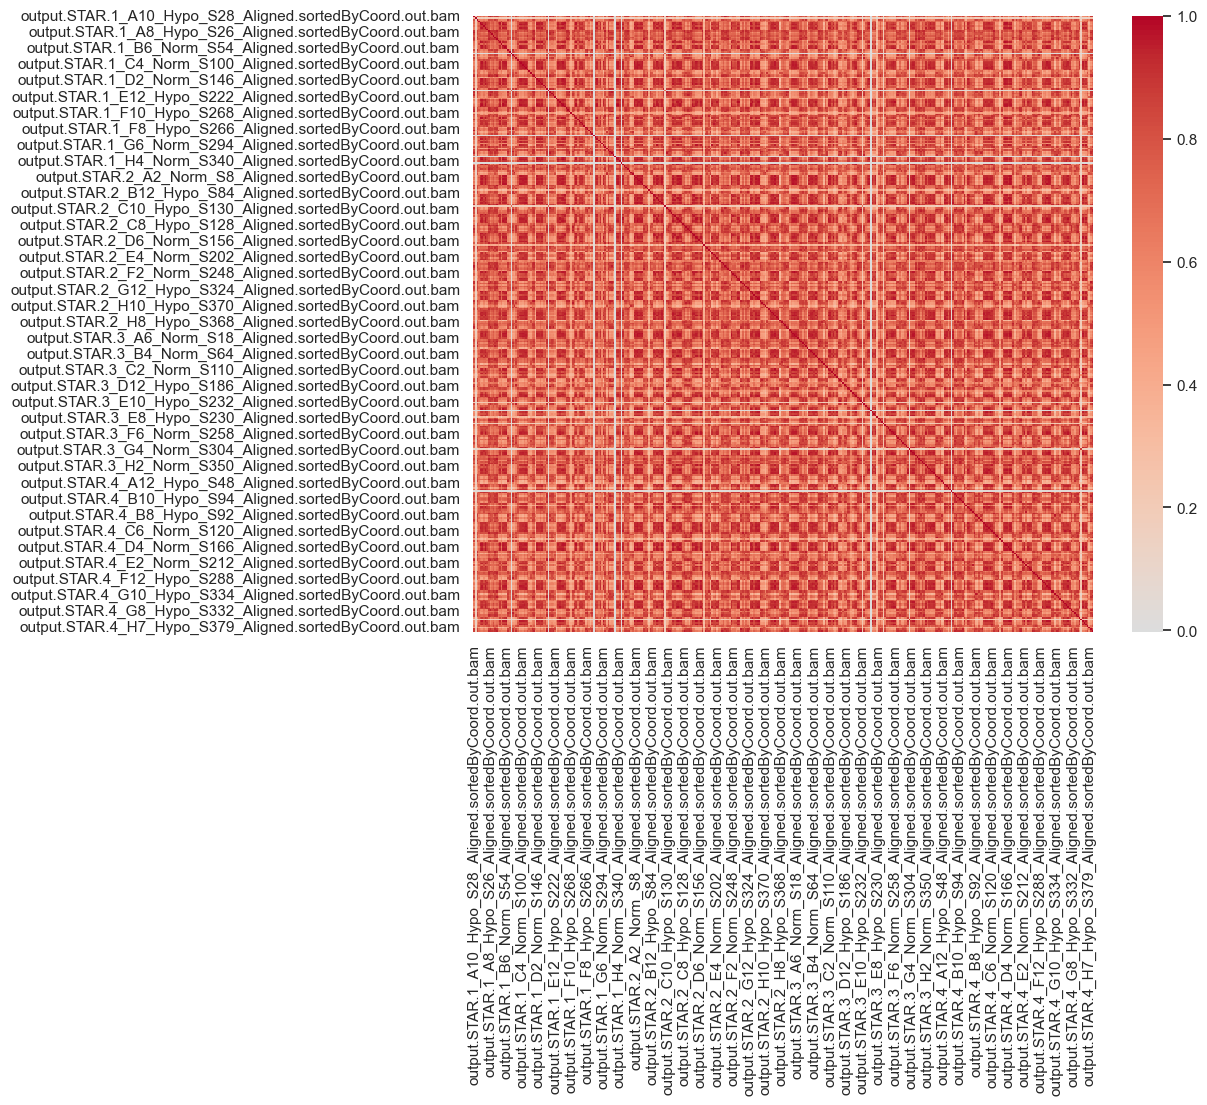

In [702]:
plt.figure(figsize=(10,8))
c= unf.T.corr()                  
midpoint = (c.values.max() - c.values.min()) /2 + c.values.min()   
sns.heatmap(c,cmap='coolwarm', center=0)  
print("Number of cells included: ", np.shape(c))
print("Average correlation of expression profiles between cells: ", midpoint)
print("Min. correlation of expression profiles between cells: ", c.values.min())

<p style="font-size:15px; line-height:1.6;">Looking at the map, we notice that some cells have very low correlation values. So, we now try to further investigate the reason for this. </p>

<p style="font-size:15px; line-height:1.6;">We first visualize the previous plot only for some of the cells, in order to select two cells that have low correlation values with all others and two of them that show high correlation values.</p>

In [703]:
unf_subset_1 = unf.iloc[:20, :]

Number of cells included:  (20, 20)


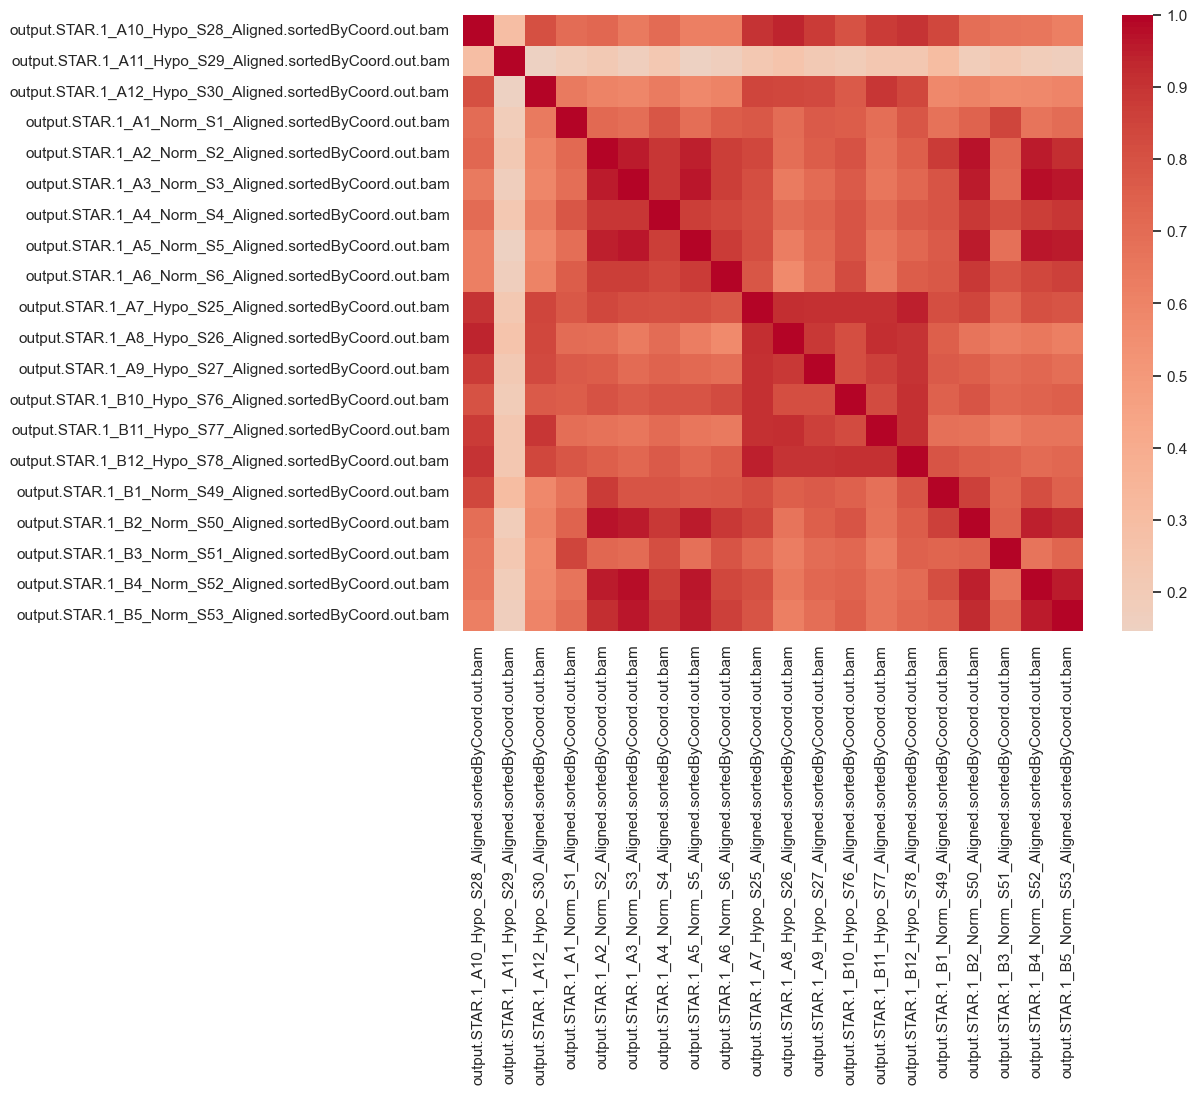

In [704]:
plt.figure(figsize=(10,8))
c= unf_subset_1.T.corr()                 
midpoint = (c.values.max() - c.values.min()) /2 + c.values.min()             
sns.heatmap(c,cmap='coolwarm', center=0)           
print("Number of cells included: ", np.shape(c))

In [705]:
correlation_sum = c.sum(axis=1)
#we take the 3 cells with the lowest correlation
low_correlation_cells = correlation_sum.nsmallest(3)
print('Cells with the lowest correlation:',low_correlation_cells )

Cells with the lowest correlation: output.STAR.1_A11_Hypo_S29_Aligned.sortedByCoord.out.bam     4.962723
output.STAR.1_A12_Hypo_S30_Aligned.sortedByCoord.out.bam    13.551563
output.STAR.1_B3_Norm_S51_Aligned.sortedByCoord.out.bam     14.053438
dtype: float64


We plot the histogram for these cells.

Cell 1: output.STAR.1_A11_Hypo_S29_Aligned.sortedByCoord.out.bam
Percentage of zero values: 99.18%

Cell 2: output.STAR.1_A12_Hypo_S30_Aligned.sortedByCoord.out.bam

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):



Percentage of zero values: 71.85%



/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Cell 3: output.STAR.1_B3_Norm_S51_Aligned.sortedByCoord.out.bam
Percentage of zero values: 64.41%



/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


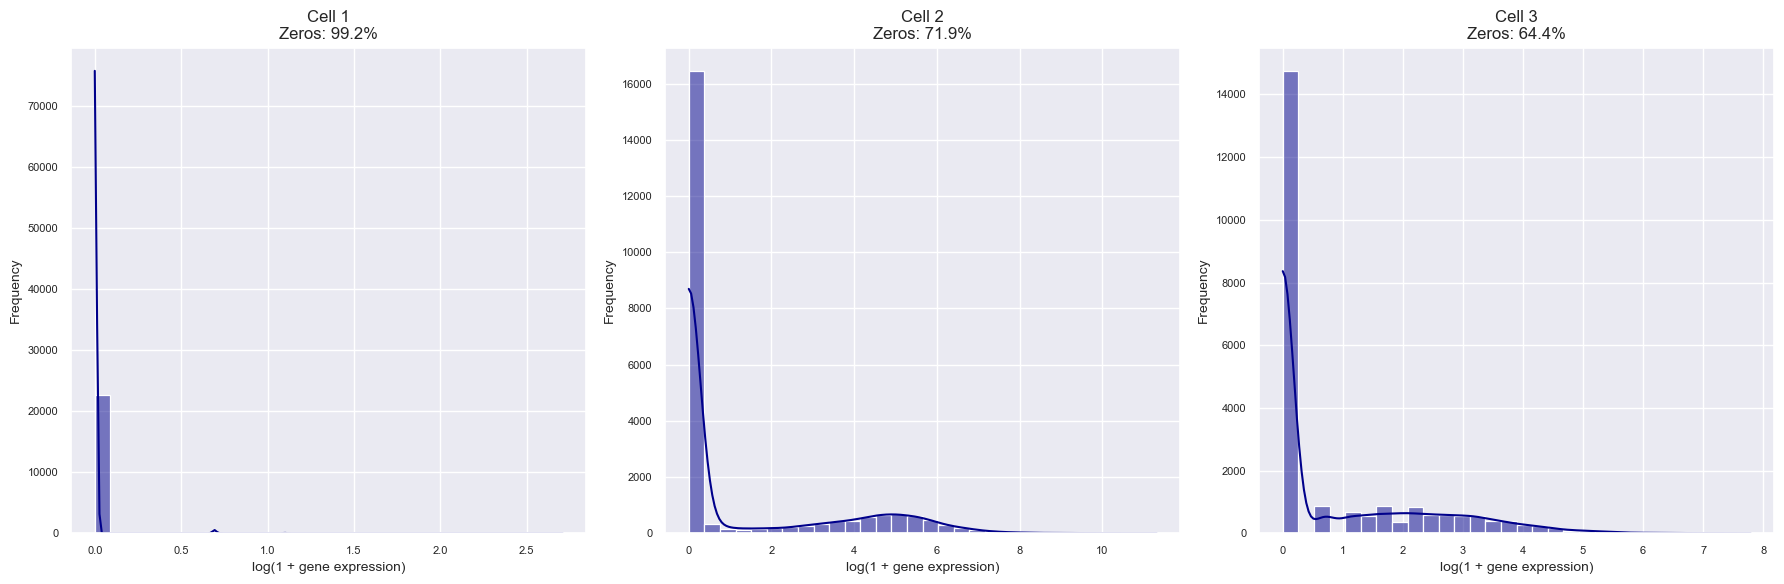

In [706]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

for i, cell in enumerate(low_correlation_cells.index):

    zero_percentage = (unf.loc[cell] == 0).mean() * 100
    print(f'Cell {i+1}: {cell}')
    print(f'Percentage of zero values: {zero_percentage:.2f}%\n')

    sns.histplot(
        np.log1p(unf.loc[cell]),
        bins=30,
        kde=True,
        color='darkblue',
        ax=axs[i]
    )

    axs[i].set_title(
        f'Cell {i+1}\nZeros: {zero_percentage:.1f}%',
        fontsize=12
    )

    axs[i].set_xlabel('log(1 + gene expression)', fontsize=10)
    axs[i].set_ylabel('Frequency', fontsize=10)

    axs[i].tick_params(axis='both', labelsize=8)
    axs[i].grid(True)

plt.tight_layout()
plt.show()

<p style="font-size:15px; line-height:1.6;">So, the low correlated cells are the ones that have almost non-zero entries. These are characterized as low quality cells and will be removed in the preprocessing section. </p>

<p style="font-size:15px; line-height:1.6;">This cell-cell correlation analysis reveals that most of the cells are generally correlated. These cells are not redundant and we will not proceed to removing them as they reflect biologically distinct and similar observations, such as them sharing the same condition/state. Of course, there are some cells that are almost not correlated at all. This could highlight the heterogeneity in the dataset or potentially could represent outliers, and thus requires further investigation. </p>

##### **Outliers** 


<p style="font-size:15px; line-height:1.6;">Studying outliers is important because it can greatly affect the results of the analysis and interpretations. If not treated and processed properly, they can potentially cause serious issues, such as skewing the data and impacting the mean, standard deviation, and correlations. This can, in turn, affect the results of clustering, dimensionality reduction, and other analysis.</p>

<p style="font-size:15px; line-height:1.6;">Having a sparse dataset, studying the outliers (so the nonzero elements most likely) becomes even more fundamental, since they have an even larger impact on the statistical properties and interpretations of the data. Indeed, we expect that simply removing outliers would not work here, as many genes/features would be 0 if we excluded the outliers.</p>

<p style="font-size:15px; line-height:1.6;">In this section, we'll try to identify the outliers and there are several methods to check them, such as:</p>

1. Visual tools

2. Z-score

3. IQR (Interquartile Range, with Tukey's rule)

and more. We'll quickly explore some of these methods.

<p style="font-size:15px; line-height:1.6;">First of all, let's visualize the violin plot and the box plot of a single column of our dataframe.</p>

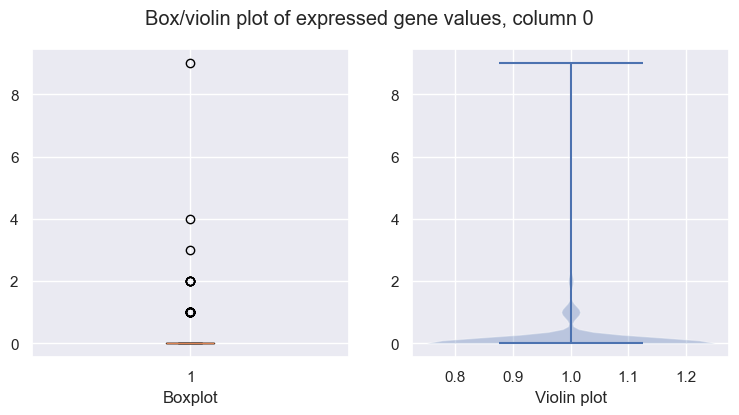

In [707]:
col = unf.iloc[:, 0]
fig, ax= plt.subplots(1,2, figsize=(9, 4))
plt.suptitle("Box/violin plot of expressed gene values, column 0")
ax[0].boxplot(col)
ax[1].violinplot(col)
ax[0].set_xlabel("Boxplot")
ax[1].set_xlabel("Violin plot")
plt.show()

<p style="font-size:15px; line-height:1.6;">The boxplot and violin plot represent the distribution of expression values of a single gene across all cells. Notice that, especially through the violin plot, most of the density of the distribution is around 0, while a small number of cells exhibit higher expression levels. This strongly indicates sparse and cell-specific gene activity.</p>

<p style="font-size:15px; line-height:1.6;">We've inspected a single cell. In order to find outliers, we apply the Interquartile Range (IQR) rule.</p>

Here's how we use IQR rule to detect outliers in our dataset:

<p style="font-size:15px; line-height:1.6;">First, we compute the quartiles of the dataset. The first quartile (Q1) is the value below which 25% of the data falls, and the third quartile (Q3) is the value below which 75% of the data falls. This divides the data into four equal parts, with the central 50% of the data between Q1 and Q3. The interquartile range (IQR) is defined as the difference between the third quartile (Q3) and the first quartile (Q1). The IQR represents the spread or variability of the middle 50% of the data. Using the IQR, we define the thresholds to identify the outliers. Values that are smaller than Q1−1.5×IQR or larger than Q3+1.5×IQR are considered to be outliers.</p>

<p style="font-size:15px; line-height:1.6;"> With this approach, we can systematically detect extreme gene expression values, which may either be biologically significant signals or just noise.</p>




**IQR for each gene across cells**

In [708]:
Q1 = unf.quantile(0.25)
Q3 = unf.quantile(0.75)
IQR = Q3 - Q1
print(IQR)

WASH7P          0.0
MIR6859-1       0.0
WASH9P          2.0
OR4F29          0.0
MTND1P23        0.0
              ...  
MT-TE           7.0
MT-CYB       3842.5
MT-TT           3.0
MT-TP           8.0
MAFIP           2.0
Length: 22905, dtype: float64


In [709]:
data_noOut = unf[~((unf < (Q1 - 1.5 * IQR)) |(unf > (Q3 + 1.5 * IQR))).any(axis=1)]
print(data_noOut.shape)

(4, 22905)


<p style="font-size:15px; line-height:1.6;">But, this reduction of the dataset results into very few datapoints. So, evidently, we should follow another way for the removal of the outliers. </p>

**IQR for each cell across its genes**

Next, we try to compute the IQR of each row of the dataset. So, we transpose the dataset.

In [710]:
unfT = unf.T
Q1 = unfT.quantile(0.25)
Q3 = unfT.quantile(0.75)
IQR = Q3 - Q1
print(IQR)

output.STAR.1_A10_Hypo_S28_Aligned.sortedByCoord.out.bam    17.0
output.STAR.1_A11_Hypo_S29_Aligned.sortedByCoord.out.bam     0.0
output.STAR.1_A12_Hypo_S30_Aligned.sortedByCoord.out.bam     5.0
output.STAR.1_A1_Norm_S1_Aligned.sortedByCoord.out.bam       0.0
output.STAR.1_A2_Norm_S2_Aligned.sortedByCoord.out.bam       7.0
                                                            ... 
output.STAR.4_H5_Norm_S359_Aligned.sortedByCoord.out.bam     9.0
output.STAR.4_H6_Norm_S360_Aligned.sortedByCoord.out.bam    27.0
output.STAR.4_H7_Hypo_S379_Aligned.sortedByCoord.out.bam    30.0
output.STAR.4_H8_Hypo_S380_Aligned.sortedByCoord.out.bam    38.0
output.STAR.4_H9_Hypo_S381_Aligned.sortedByCoord.out.bam    33.0
Length: 383, dtype: float64


In [711]:
data_noOut_T = unfT[~((unfT < (Q1 - 1.5 * IQR)) |(unfT > (Q3 + 1.5 * IQR))).any(axis=1)]
data_noOut = data_noOut_T.T
print(data_noOut.shape)

(383, 6424)


In [712]:
print("Difference of number of columns:", unf.shape[1]-data_noOut.shape[1])

Difference of number of columns: 16481


In [713]:
print("Percentage of removed columns:", (unf.shape[1]-data_noOut.shape[1])/unf.shape[1]*100, "%")

Percentage of removed columns: 71.9537218947828 %


<p style="font-size:15px; line-height:1.6;">When applying the IQR filtering on the transposed dataset, we removed 16,481 genes, which is over 70% of the total. However, we believe the outliers in gene expression data must be handled with caution. Since the data represents RNA sequencing counts, extreme values are not necessarily errors but may instead carry important information about the cells and their condition. For this reason, we will retain the outliers and we will investigate further in the following steps. </p>

##### **Plots**

<p style="font-size:15px; line-height:1.6;">To confirm with another method that outliers shouldn't be removed from the dataset, we proceed with selecting a cell randomly and we provide its violin plot.</p>

101


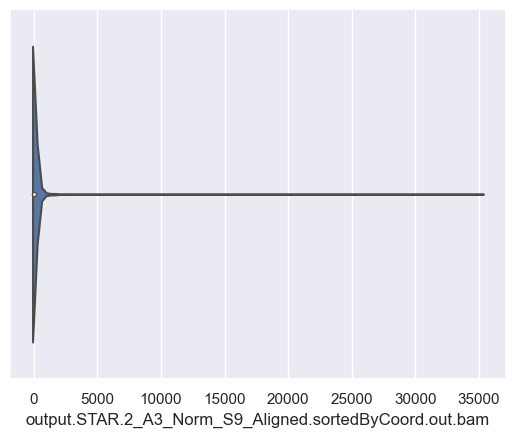

In [714]:
rows = list(unf.index)
random.seed(88)
ind1 = random.randint(0,243)
print(ind1)
sns.violinplot(x= unf.loc[rows[ind1]])
plt.show()

<p style="font-size:15px; line-height:1.6;">As we can see, the distribution of the gene expression is concentrated near 0 and there is a very long right tail. That indicates that most values are, if not close to 0, equal to 0 and therefore most genes are not expressed in most cells. So, the dataset is highly sparse. Moreover, the distribution is highly right-skewed, having a few very large values. </p>

And then the violin plot for the same random cell, without its outliers.

101


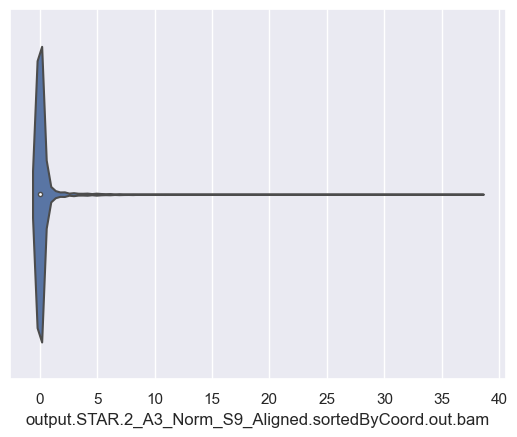

In [715]:
print(ind1)
sns.violinplot(x= data_noOut.loc[rows[ind1]])
plt.show()

<p style="font-size:15px; line-height:1.6;">Even though, the extreme long right tail is gone as the scale is smaller (up to 40), the distribution is still heavily skewed, centered around 0, and still very sparse. So, removing outliers does not change the underlying structure of this data.</p>

Here, is the distributions of 30 random cells:

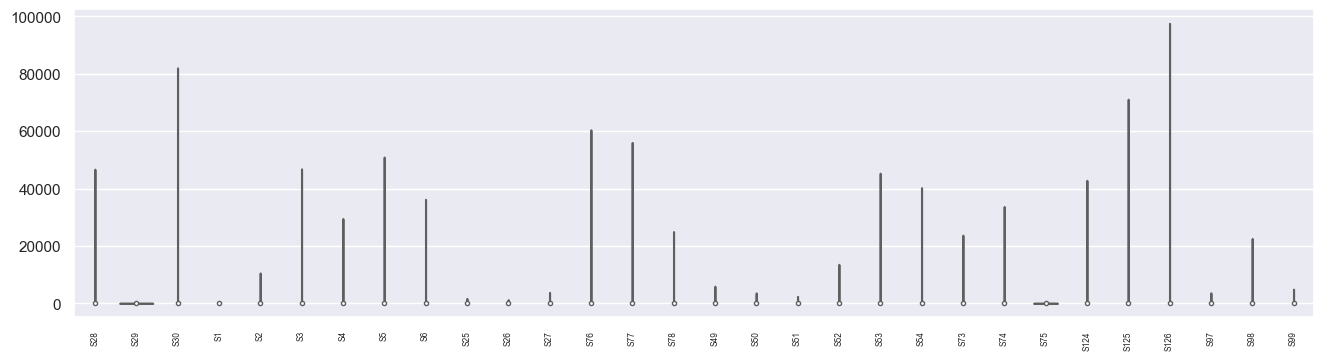

In [716]:
names = [i for i in meta["Cell name"]]      

data_small = unf.T.iloc[:, :30]  
names_small = names[:30]               
plt.figure(figsize=(16,4))

plot=sns.violinplot(data=data_small, palette="Set3", cut=0)
plot.set_xticklabels(names_small, rotation=90, fontsize=6)
plt.setp(plot.get_xticklabels(), rotation=90)
plt.show()

Let's visualize the plot of the previously randomly chosen single cells excluding outliers:

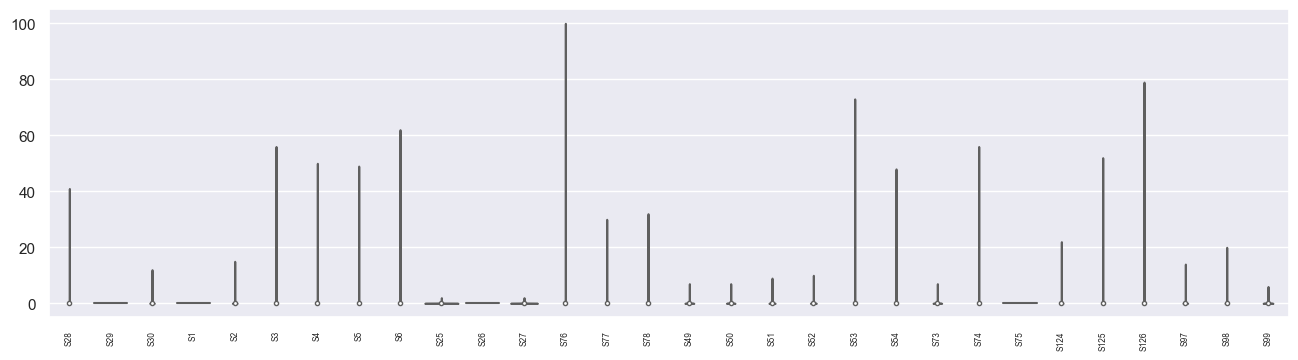

In [717]:
data_noOut_small = data_noOut.T.iloc[:, :30]
names_small = names[:30]
plt.figure(figsize=(16,4))

plot=sns.violinplot(data=data_noOut_small, palette="Set3", cut=0)
plot.set_xticklabels(names_small, rotation=90, fontsize=6)
plt.setp(plot.get_xticklabels(), rotation=90)
plt.show()

<p style="font-size:15px; line-height:1.6;">The important message of this section is that our data is sparse. So, we proceed with an investigation on the sparsity of the data.</p>

##### **Sparsity of the data**


<p style="font-size:15px; line-height:1.6;">It is normal, as in any gene expression dataset, to be characterized by a high degree of sparsity, meaning that a large amount of entries in the data are zero or almost. This is because in a given cell, only a number of genes are actively expressed. So, this strongly influences the modelling process and thus should be carefully considered during the preprocessing analysis. </p>

<p style="font-size:15px; line-height:1.6;">We proceed with calculating the sparsity and its index. We divide the number of zero values by the total number of elements and then times 100.</p>

In [718]:
n_zeros = np.count_nonzero(unf==0)              
print('Total number of 0 values in the DataFrame:', n_zeros)
sp = n_zeros / unf.size
print('Sparsity percentage:', sp*100, '%')

Total number of 0 values in the DataFrame: 5278229
Sparsity percentage: 60.16711094696393 %


A visualization of the sparsity of the dataset.

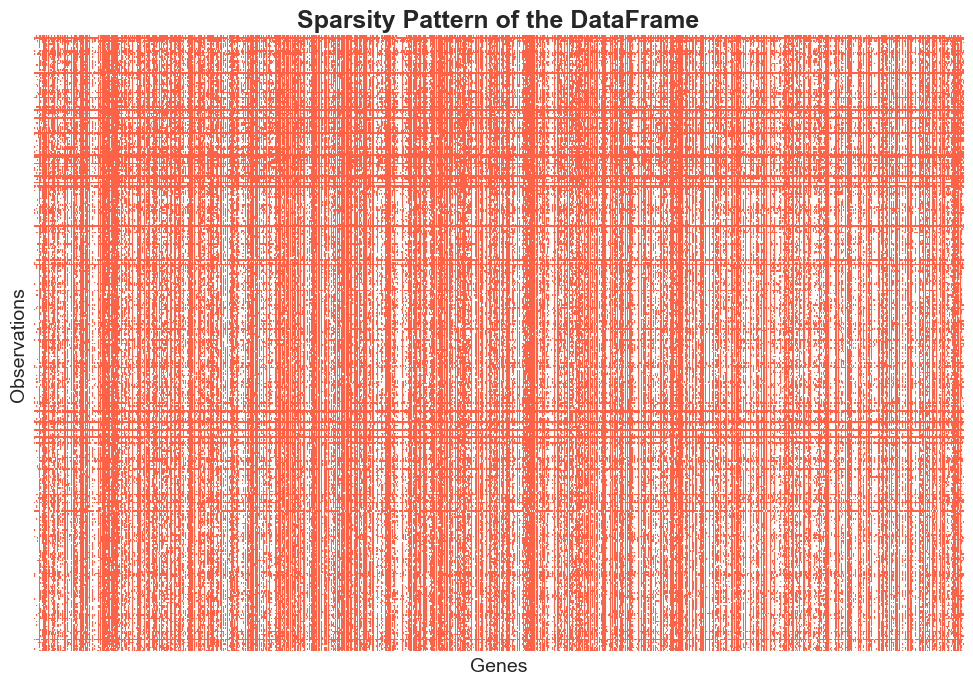

In [719]:
missing_mask = unf == 0

colors = ["#FFFFFF", "#FF6347"] 


plt.figure(figsize=(12, 8))
sns.heatmap(missing_mask, cmap=sns.color_palette(colors), cbar=False, xticklabels=False, yticklabels=False)

plt.title('Sparsity Pattern of the DataFrame', fontsize=18, fontweight='bold')
plt.xlabel('Genes', fontsize=14)
plt.ylabel('Observations', fontsize=14)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

In the dataset without outliers, we obtain:

In [720]:
n_zeros_noout = np.count_nonzero(data_noOut==0)                # count the number of elements in the boolean mask (data == 0) that are true, so the number of 0 elements
print('Number of 0 values in the matrix:', n_zeros_noout)

sp_noout = n_zeros_noout / data_noOut.size
print('Sparsity index:', sp_noout*100, '%')

Number of 0 values in the matrix: 2349283
Sparsity index: 95.48409359159028 %


<p style="font-size:15px; line-height:1.6;">Although many genes contain a high proportion of zeros, these values are not meaningless. A zero often indicates that a gene is not expressed in a specific cell, rather than missing or irrelevant information. Therefore, removing such features would result in a loss of potentially important biological information. Similarly, outlier removal proves to be ineffective: after removing outliers, the sparsity increases significantly (to about 95.5%), further reinforcing that sparsity is naturally present in the data. To address this, we will try to reduce the dimensions while preserving the most informative patterns.</p>

Before moving on, we do a last check that non of the columns or rows contain only 0 values.

In [ ]:
zero_columns = []
for column in unf.columns:
    if (unf[column] == 0).all():
        zero_columns.append(column)
if zero_columns == []:
    print ("There are no columns full of 0")
zero_rows = []
for index, row in unf.iterrows():
    if (row == 0).all():
        zero_rows.append(index)
if zero_rows == []:
    print("There are no rows full of 0")

There are no columns full of 0
There are no rows full of 0


##### **Data Distribution** 


We start with the distribution of gene expression counts for 3 randomly chosen genes. 

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


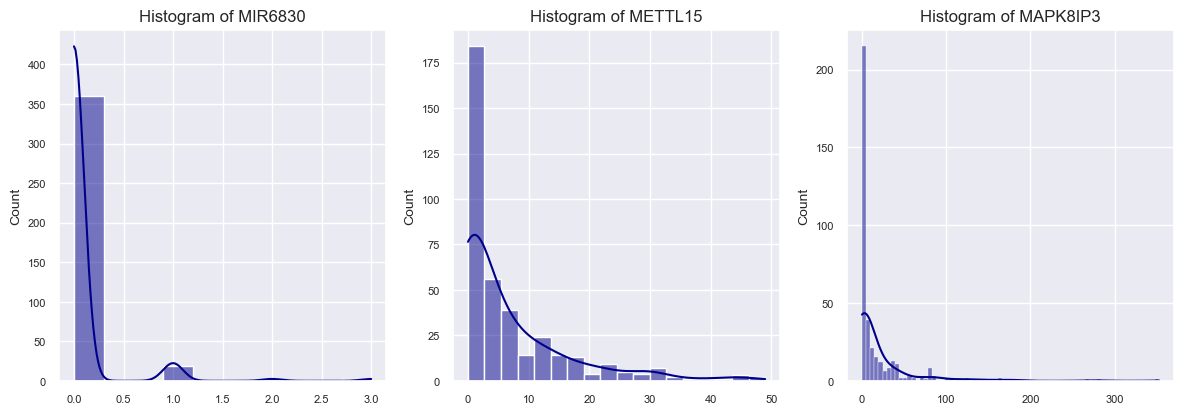

In [ ]:
np.random.seed(42)
num_boxplots = 3

random_columns = np.random.choice(unf.columns[1:], num_boxplots, replace=False)

fig = plt.figure(figsize=(12, 8))
for i, column in enumerate(random_columns):  
    plt.subplot(2, 3, i+1) 
    sns.histplot(unf[column], kde=True, color='darkblue')
    plt.title(f'Histogram of {column}', fontsize=12)
    plt.xlabel('')
    plt.ylabel('Count', fontsize=10)
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    plt.grid(True)
plt.tight_layout()
plt.show()


<p style="font-size:15px; line-height:1.6;">So, the data is highly asymmetrical. To further investigate this, we proceed with the skewness and kurtosis of these distributions for all the genes.</p>

**Skewness of Genes**

<p style="font-size:15px; line-height:1.6;">Skewness is a measure of symmetry. We will consider the skewness of our data by calculating how skewed each sample's data is, then plotting the distribution of those skewness values.

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


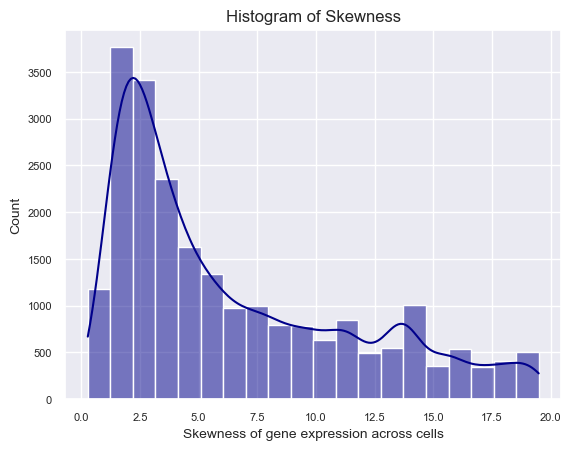

Mean Skewness: 6.479831302203512


In [723]:
unf_skew_genes = [skew(unf[col]) for col in unf.columns]
sns.histplot(unf_skew_genes, kde=True, color='darkblue', bins=20)

plt.title("Histogram of Skewness", fontsize=12)
plt.xlabel("Skewness of gene expression across cells", fontsize=10)
plt.ylabel("Count", fontsize=10)

plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.grid(True)
plt.show()
print("Mean Skewness:", np.mean(unf_skew_genes))

<p style="font-size:15px; line-height:1.6;">The histogram shows the distribution of skewness values across genes. Each bar represents the number of genes whose skewness falls within a given interval. So, gene expression distributions are highly asymmetric and right-skewed.</p>

**Kurtosis**

<p style="font-size:15px; line-height:1.6;">Kurtosis describes the shape of a distribution's tails, identifying how often extreme outliers occur with respect to a normal distribution. Higher kurtosis means a higher frequency of extreme outliers, which is what we expect from our data considering the previous analysis conducted on the outliers in our data.

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


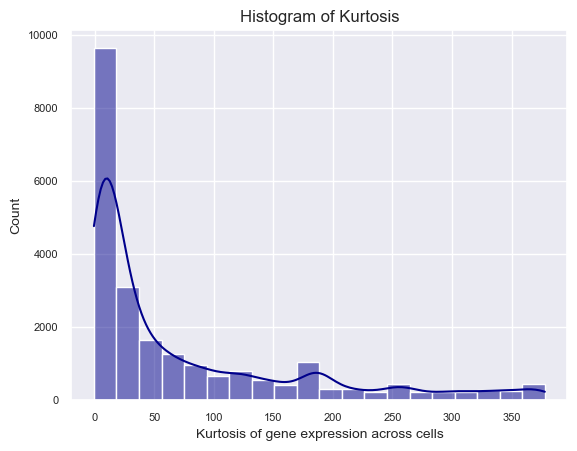

Mean Kurtosis: 74.45421175502999


In [724]:
unf_kurt_genes = [kurtosis(unf[col]) for col in unf.columns]

sns.histplot(unf_kurt_genes, kde=True, color='darkblue', bins=20)

plt.title("Histogram of Kurtosis", fontsize=12)
plt.xlabel("Kurtosis of gene expression across cells", fontsize=10)
plt.ylabel("Count", fontsize=10)

plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.grid(True)
plt.show()
print("Mean Kurtosis:", np.mean(unf_kurt_genes))

<p style="font-size:15px; line-height:1.6;">This histogram show that most of the genes have a positive kurtosis and in general, many gene expression distributions are heavy-tailed.</p>

<p style="font-size:15px; line-height:1.6;"> These confirm that the data deviate strongly from the Gaussian distribution and supports the need for preprocessing techniques aiming at reducing skewness, such as log transformation and dimensionality reduction. </p>

### **Data Preprocessing** 

##### **Quality Control**


<p style="font-size:15px; line-height:1.6;">As previously discussed, we will now need to remove the low-quality cells based on the number of counts per cell and the number of detected genes per cell. </p>

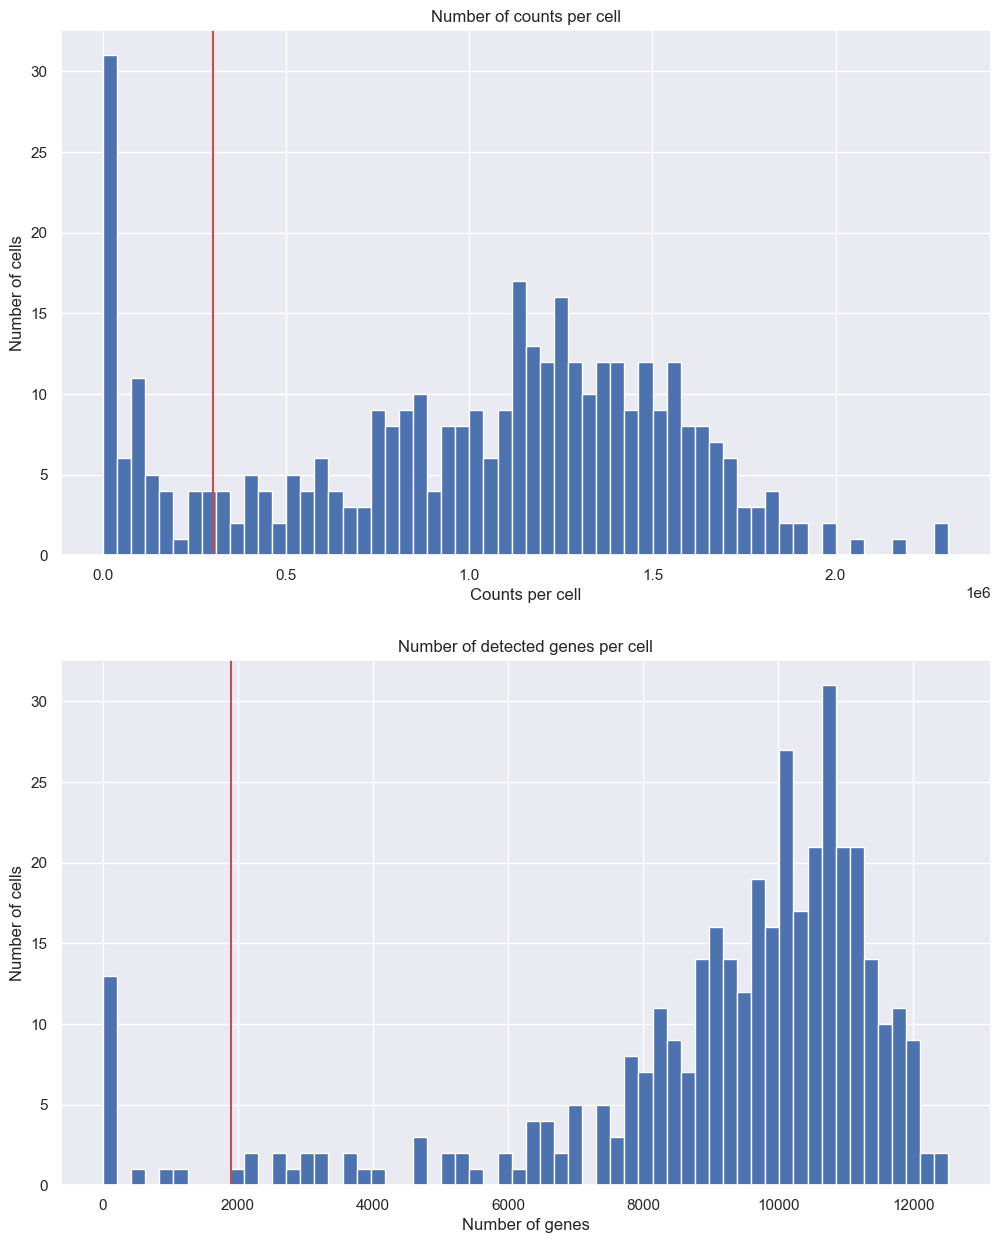

In [725]:
counts_per_cell = unf.T.sum(axis = 0) 
number_of_genes = np.count_nonzero(unf.T, axis=0) 

counts_per_cell_threshold = 300000
number_of_genes_threshold = 1900

fig, ax = plt.subplots(2, 1, figsize = (12, 15))

ax[0].set_title("Number of counts per cell")
ax[0].hist(counts_per_cell, bins = 60)
ax[0].axvline(counts_per_cell_threshold, color = "r")
ax[0].set_xlabel("Counts per cell")
ax[0].set_ylabel("Number of cells")
ax[0].grid(True)
ax[1].set_title("Number of detected genes per cell")
ax[1].hist(number_of_genes, bins = 60)
ax[1].axvline(number_of_genes_threshold, color = "r")
ax[1].set_xlabel("Number of genes")
ax[1].set_ylabel("Number of cells")
ax[1].grid(True)
plt.show()

In [726]:
good_cells = (
    (counts_per_cell >= counts_per_cell_threshold) &
    (number_of_genes >= number_of_genes_threshold)
)

filtered_data = unf.loc[good_cells, :]

filtered_meta = meta.loc[filtered_data.index]

condition_counts = filtered_meta["Condition"].value_counts()

print(condition_counts)

Condition
Hypo    160
Norm    157
Name: count, dtype: int64


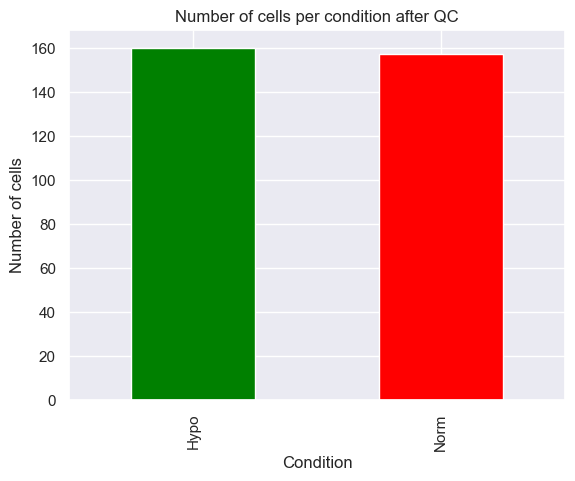

In [727]:
condition_counts.plot(kind='bar', color=['green', 'red'])
plt.title("Number of cells per condition after QC")
plt.xlabel("Condition")
plt.ylabel("Number of cells")
plt.grid(True)

plt.show()

So, the dataset is still balanced.

In [728]:
unf = unf.T.loc[:, (number_of_genes > number_of_genes_threshold) & (counts_per_cell > counts_per_cell_threshold)]
unf

,output.STAR.1_A10_Hypo_S28_Aligned.sortedByCoord.out.bam,output.STAR.1_A12_Hypo_S30_Aligned.sortedByCoord.out.bam,output.STAR.1_A2_Norm_S2_Aligned.sortedByCoord.out.bam,output.STAR.1_A3_Norm_S3_Aligned.sortedByCoord.out.bam,output.STAR.1_A4_Norm_S4_Aligned.sortedByCoord.out.bam,output.STAR.1_A5_Norm_S5_Aligned.sortedByCoord.out.bam,output.STAR.1_A6_Norm_S6_Aligned.sortedByCoord.out.bam,output.STAR.1_B10_Hypo_S76_Aligned.sortedByCoord.out.bam,output.STAR.1_B11_Hypo_S77_Aligned.sortedByCoord.out.bam,output.STAR.1_B12_Hypo_S78_Aligned.sortedByCoord.out.bam,...,output.STAR.4_H14_Hypo_S383_Aligned.sortedByCoord.out.bam,output.STAR.4_H1_Norm_S355_Aligned.sortedByCoord.out.bam,output.STAR.4_H2_Norm_S356_Aligned.sortedByCoord.out.bam,output.STAR.4_H3_Norm_S357_Aligned.sortedByCoord.out.bam,output.STAR.4_H4_Norm_S358_Aligned.sortedByCoord.out.bam,output.STAR.4_H5_Norm_S359_Aligned.sortedByCoord.out.bam,output.STAR.4_H6_Norm_S360_Aligned.sortedByCoord.out.bam,output.STAR.4_H7_Hypo_S379_Aligned.sortedByCoord.out.bam,output.STAR.4_H8_Hypo_S380_Aligned.sortedByCoord.out.bam,output.STAR.4_H9_Hypo_S381_Aligned.sortedByCoord.out.bam
WASH7P,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,1
MIR6859-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
WASH9P,1,0,0,1,10,1,0,5,4,1,...,1,1,0,0,0,0,1,1,4,5
OR4F29,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
MTND1P23,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MT-TE,4,0,3,3,0,0,14,9,3,0,...,0,4,12,4,0,1,6,0,7,4
MT-CYB,270,76,727,2717,9326,3253,7949,2853,570,215,...,239,3795,12761,2263,1368,570,3477,349,2184,1149
MT-TT,0,0,0,1,1,1,4,2,4,0,...,0,7,4,2,0,0,3,0,2,2
MT-TP,5,0,0,1,1,4,2,5,7,2,...,0,14,56,11,2,0,7,2,28,11


<p style="font-size:15px; line-height:1.6;">Based on the quality control filtering and the visual inspection of the histograms, we decided to put as thresholds 300000 total counts and 1900 detected-genes. That is because, the detected-genes graph showed a clear low-value tail separated from the main population, making it a reliable criterion. Although the counts-per-cell distribution exhibited a more gradual transition, it is still a good indicator of cell quality. These thresholds are considered heuristic rather than strictly optimal. So, the number of cells got reduced from 383 to 317. </p>

##### **Data Transformation**

<p style="font-size:15px; line-height:1.6;">Having completed the EDA and the quality-control filtering, we proceed with transforming the data in order to reduce overdispersion and mitigate the strong skewness and kurtosis. To do so, we will aply concave transformations, which can help compress the extreme values and stabilize the variance. </p>

<p style="font-size:15px; line-height:1.6;">We focus on the transposed dataset, meaning that gene expression distributions are analyzed across cells. In particular, we compare two commonly used transformations: the logarithmic transformation and the square-root transformation.</p>

**Square Root Transformation**

In [729]:
unf_sqrt = np.sqrt(unf)

sqrt_skew = [skew(unf_sqrt[col]) for col in unf_sqrt.columns]
sqrt_kurt = [kurtosis(unf_sqrt[col]) for col in unf_sqrt.columns]

mean_skewness_sqrt = np.mean(sqrt_skew)
mean_kurtosis_sqrt = np.mean(sqrt_kurt)

print(f"Mean skewness after square-root transformation: {mean_skewness_sqrt:.2f}")
print(f"Mean kurtosis after square-root transformation: {mean_kurtosis_sqrt:.2f}")

Mean skewness after square-root transformation: 7.27
Mean kurtosis after square-root transformation: 148.51


**Log Transformation**

In [730]:
unf_log2 = np.log2(unf+1)

unf_log2_skew_genes = [skew(unf_log2[col]) for col in unf_log2.columns] 
unf_log2_kurt_genes = [kurtosis(unf_log2[col]) for col in unf_log2.columns]

mean_skewness = np.mean(unf_log2_skew_genes)
mean_kurtosis = np.mean(unf_log2_kurt_genes)

print(f"Mean skewness after log transformation: {mean_skewness:.2f}")
print(f"Mean kurtosis after log transformation: {mean_kurtosis:.2f}")

Mean skewness after log transformation: 0.95
Mean kurtosis after log transformation: -0.28


It is clear that, indeed, the log transformation is the best.

Let's visualize skewness and kurtosis of the transformed data:

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


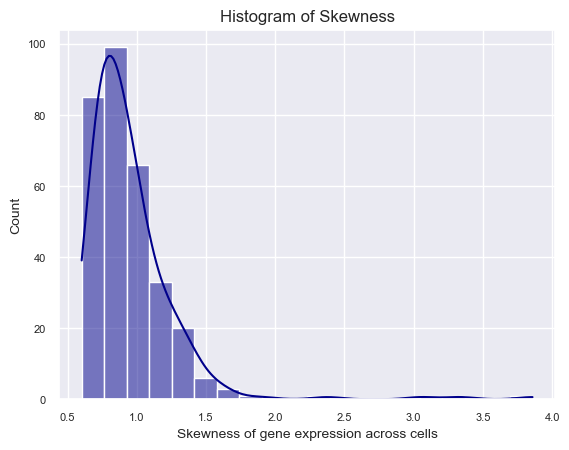

In [731]:
sns.histplot(unf_log2_skew_genes, kde=True, color='darkblue', bins=20)

plt.title("Histogram of Skewness", fontsize=12)
plt.xlabel("Skewness of gene expression across cells", fontsize=10)
plt.ylabel("Count", fontsize=10)

plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.grid(True)
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


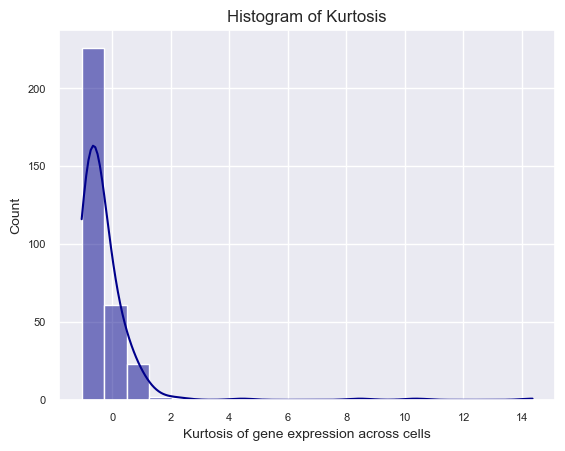

In [732]:
sns.histplot(unf_log2_kurt_genes, kde=True, color='darkblue', bins=20)

plt.title("Histogram of Kurtosis", fontsize=12)
plt.xlabel("Kurtosis of gene expression across cells", fontsize=10)
plt.ylabel("Count", fontsize=10)

plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.grid(True)
plt.show()

<p style="font-size:15px; line-height:1.6;">Taking a log transformation, the dataset is still not perfectly following a normal distribution but the resulting values of skewness and kurtosis are lower than the ones of the original dataset: rescaling it is therefore a good idea by the reasoning above.</p>

We now proceed in normalizing the data and then logging it. 

##### **Normalization**


<p style="font-size:15px; line-height:1.6;">We apply CPM normalization, which is a standard technique for RNA-seq data. For each cell, gene counts are divided by the total number of reads in that cell and multiplied by one million. This normalization is performed across cells to correct the differences and make the gene expressions comparable between observations.</p>

In [733]:
unf_cpm = pd.DataFrame()
for column in unf.columns:
    cpm = unf[column] / unf[column].sum() * 1e6
    unf_cpm = pd.concat([unf_cpm, cpm], axis=1)

In [734]:
unf_cpm.shape

(22905, 317)

In [735]:
unf_cpm.head()

,output.STAR.1_A10_Hypo_S28_Aligned.sortedByCoord.out.bam,output.STAR.1_A12_Hypo_S30_Aligned.sortedByCoord.out.bam,output.STAR.1_A2_Norm_S2_Aligned.sortedByCoord.out.bam,output.STAR.1_A3_Norm_S3_Aligned.sortedByCoord.out.bam,output.STAR.1_A4_Norm_S4_Aligned.sortedByCoord.out.bam,output.STAR.1_A5_Norm_S5_Aligned.sortedByCoord.out.bam,output.STAR.1_A6_Norm_S6_Aligned.sortedByCoord.out.bam,output.STAR.1_B10_Hypo_S76_Aligned.sortedByCoord.out.bam,output.STAR.1_B11_Hypo_S77_Aligned.sortedByCoord.out.bam,output.STAR.1_B12_Hypo_S78_Aligned.sortedByCoord.out.bam,...,output.STAR.4_H14_Hypo_S383_Aligned.sortedByCoord.out.bam,output.STAR.4_H1_Norm_S355_Aligned.sortedByCoord.out.bam,output.STAR.4_H2_Norm_S356_Aligned.sortedByCoord.out.bam,output.STAR.4_H3_Norm_S357_Aligned.sortedByCoord.out.bam,output.STAR.4_H4_Norm_S358_Aligned.sortedByCoord.out.bam,output.STAR.4_H5_Norm_S359_Aligned.sortedByCoord.out.bam,output.STAR.4_H6_Norm_S360_Aligned.sortedByCoord.out.bam,output.STAR.4_H7_Hypo_S379_Aligned.sortedByCoord.out.bam,output.STAR.4_H8_Hypo_S380_Aligned.sortedByCoord.out.bam,output.STAR.4_H9_Hypo_S381_Aligned.sortedByCoord.out.bam
WASH7P,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.332042,0.0,0.0,0.000000,0.708476,0.000000,0.693754
MIR6859-1,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
WASH9P,1.068248,0.0,0.0,0.775674,5.783165,0.694678,0.0,2.186113,2.475006,1.062819,...,2.511345,1.036196,0.000000,0.000000,0.0,0.0,0.885478,0.708476,2.554039,3.468768
OR4F29,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.638510,0.000000
MTND1P23,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.256858,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000


In [736]:
unf_cpm.describe()

,output.STAR.1_A10_Hypo_S28_Aligned.sortedByCoord.out.bam,output.STAR.1_A12_Hypo_S30_Aligned.sortedByCoord.out.bam,output.STAR.1_A2_Norm_S2_Aligned.sortedByCoord.out.bam,output.STAR.1_A3_Norm_S3_Aligned.sortedByCoord.out.bam,output.STAR.1_A4_Norm_S4_Aligned.sortedByCoord.out.bam,output.STAR.1_A5_Norm_S5_Aligned.sortedByCoord.out.bam,output.STAR.1_A6_Norm_S6_Aligned.sortedByCoord.out.bam,output.STAR.1_B10_Hypo_S76_Aligned.sortedByCoord.out.bam,output.STAR.1_B11_Hypo_S77_Aligned.sortedByCoord.out.bam,output.STAR.1_B12_Hypo_S78_Aligned.sortedByCoord.out.bam,...,output.STAR.4_H14_Hypo_S383_Aligned.sortedByCoord.out.bam,output.STAR.4_H1_Norm_S355_Aligned.sortedByCoord.out.bam,output.STAR.4_H2_Norm_S356_Aligned.sortedByCoord.out.bam,output.STAR.4_H3_Norm_S357_Aligned.sortedByCoord.out.bam,output.STAR.4_H4_Norm_S358_Aligned.sortedByCoord.out.bam,output.STAR.4_H5_Norm_S359_Aligned.sortedByCoord.out.bam,output.STAR.4_H6_Norm_S360_Aligned.sortedByCoord.out.bam,output.STAR.4_H7_Hypo_S379_Aligned.sortedByCoord.out.bam,output.STAR.4_H8_Hypo_S380_Aligned.sortedByCoord.out.bam,output.STAR.4_H9_Hypo_S381_Aligned.sortedByCoord.out.bam
count,22905.000000,22905.000000,22905.000000,22905.000000,22905.000000,22905.000000,22905.000000,22905.000000,22905.000000,22905.000000,...,22905.000000,22905.000000,22905.000000,22905.000000,22905.000000,22905.000000,22905.000000,22905.000000,22905.000000,22905.000000
mean,43.658590,43.658590,43.658590,43.658590,43.658590,43.658590,43.658590,43.658590,43.658590,43.658590,...,43.658590,43.658590,43.658590,43.658590,43.658590,43.658590,43.658590,43.658590,43.658590,43.658590
std,497.806257,523.213016,371.712947,390.872719,249.101501,361.574544,297.587197,452.899651,513.117161,393.481362,...,485.380233,266.233927,855.153583,400.250590,304.406311,495.823564,318.383175,383.416868,406.916161,545.404361
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.694678,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,18.160220,2.522179,21.004495,17.840494,22.554343,24.313745,24.584697,19.237790,19.800044,24.444837,...,22.602105,31.085892,0.000000,22.644716,23.791539,22.502869,23.907917,21.254286,24.263367,22.893868
max,49934.195908,41387.440458,31752.795098,36344.963784,17079.999098,35409.148220,23443.449052,26441.030708,34692.152624,26564.097550,...,44701.941019,24200.367228,103002.004688,39348.524830,24086.950143,48218.647878,24811.990795,28840.649531,29538.095722,47723.308872


In [737]:
unf_cpm_log = np.log2(unf_cpm+1)

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

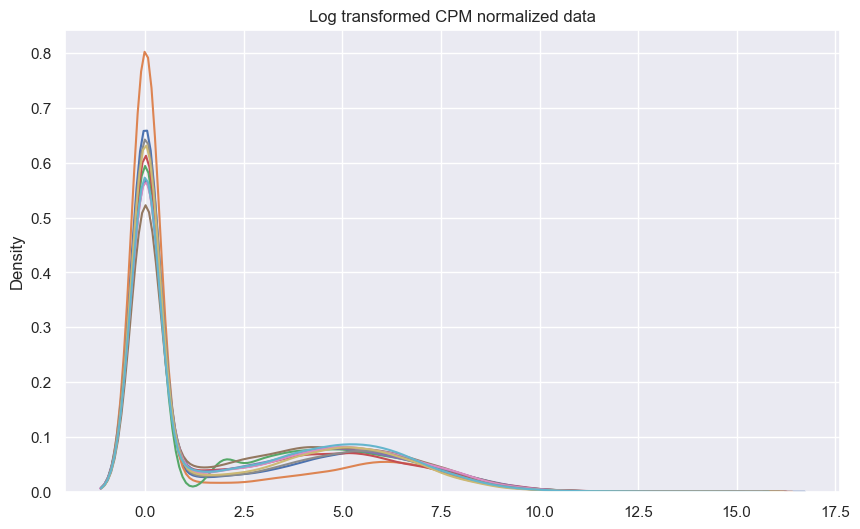

In [738]:
fig, ax = plt.subplots(1, 1, figsize=(10,6))
for i in range(10):
    sns.kdeplot(unf_cpm_log.iloc[:, i], ax=ax)
ax.set_title("Log transformed CPM normalized data")
ax.set_xlabel("")
ax.grid(True)
plt.show()

<p style="font-size:15px; line-height:1.6;">The plots of the log-transformed CPM-normalized data show a bimodal distribution across cells. There is a sharp near 0, indicating that a large number of genes are either not expressed or expressed at extremely low levels in each cell. This is, of course expected in single-cell RNA-sequencing data due to its sparse nature. There is also a second peak around 4-6, correspoding to genes that are actively expressed. The presence of this second peak suggests that the majority of the genes tend to have comparable expression levels across cells. </p>

<p style="font-size:15px; line-height:1.6;">Compared to the raw data, the distributions now are more balanced and less skewed. Extreme values are compressed, reducing the influence of highly expressed genes, while preserving the biological structure of this data. </p>

In [739]:
unf = unf_cpm_log

##### **Feature Selection**

<p style="font-size:15px; line-height:1.6;">As a last step to the preprocessing, we perform highly variable gene (HVG) selection in order to retain the genes that contain the most biologically information variability across cells. </p>

<p style="font-size:15px; line-height:1.6;">Not all genes contribute equally to the analysis. Many are the genes that are expressed at very low levels or remain almost constant across cells, making them less useful for disinguishing the two biological conditions. Therefore, feature selection was performed to identify the 3000 most informative genes. </p>

<p style="font-size:15px; line-height:1.6;">First, we cleaned the names of the genes to ensure consistency between our dataset and the filtered and normalised provided. For each gene, we computed the mean expression across cells and the variance across cells.  Since highly expressed genes naturally tend to have larger variances, we calculated the dispersion, defined as the division between variance over mean. This allows variability to be evaluated relative to the average expression level of each gene.</p>

<p style="font-size:15px; line-height:1.6;">Then, we applied a logarithmic transformation to both the mean expression and the dispersion values to reduce the influence of extreme values. 
The genes were then ranked according to their normalized variability, and the top 3000 genes with the highest log-dispersion values were selected as highly variable genes.</p>



In [740]:
fil = pd.read_csv("/Users/nikimaz/Documents/Bocconi Courses Year Two 2025-2026/AI LAB/MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt",delimiter="\ ",engine='python',index_col=0)

In [741]:
unf.shape

(22905, 317)

In [742]:
unf.index = unf.index.astype(str).str.replace('"', '', regex=False).str.strip()
fil.index = fil.index.astype(str).str.replace('"', '', regex=False).str.strip()

# mean and variance of each gene
gene_means = unf.mean(axis=1)
gene_vars = unf.var(axis=1)

# normalized dispersion
dispersion = gene_vars / gene_means
dispersion = dispersion.replace([np.inf, -np.inf], np.nan).dropna()

# log transform
log_means = np.log1p(gene_means.loc[dispersion.index])
log_dispersion = np.log1p(dispersion)

# top 3000 genes
top_genes = log_dispersion.sort_values(ascending=False).head(3000).index


In [743]:
print(top_genes)

Index(['OAS2', 'HAPLN1', 'IFIT3', 'CYP1A1', 'DHH', 'KRT6A', 'BTN3A2', 'PADI4',
       'LRRC15', 'MAGEA4-AS1',
       ...
       'GCNT2', 'RHEX', 'PEX6', 'CLSTN2', 'CORO2B', 'UNC13A', 'FMR1-AS1',
       'OR8G5', 'SAPCD1', 'TRIM21'],
      dtype='object', length=3000)


**Comparison with the filtered dataset provided**

<p style="font-size:15px; line-height:1.6;">Finally, the selected genes were compared with the genes contained in the provided filtered and normalized dataset.</p>

We find the common genes:

In [744]:
common_genes = set(top_genes).intersection(set(fil.index))

print("Common genes:", len(common_genes))
print("Percentage overlap:", len(common_genes)/3000 * 100)

Common genes: 1781
Percentage overlap: 59.36666666666667


<p style="font-size:15px; line-height:1.6;">Interestingly, the overlap between our dataset and the prefiltered and normalized one is satisfyingly high, with almost 60% of gene correspondence. Therefore, we conclude that our analysis was in the right path. </p>